# Diabetes Prediction — Gradient Boosting + XAI

| | |
|---|---|
| **Student** | Abdallah Saed — 202201933 |
| **Dataset** | BRFSS 2015 Diabetes Health Indicators |
| **Model** | Gradient Boosting Classifier |
| **XAI** | SHAP · LIME · Permutation Importance · PDP + ICE |

## 1. Install and Import Libraries

In [ ]:
!pip install lightgbm shap lime scikit-learn imbalanced-learn pandas numpy matplotlib seaborn -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, precision_recall_curve, average_precision_score,
    fbeta_score
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from imblearn.over_sampling import SMOTE
import lightgbm as lgb
import shap
import lime
import lime.lime_tabular

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='Set2')

print(f"LightGBM: {lgb.__version__}  |  SHAP: {shap.__version__}")
print("All libraries imported.")

LightGBM: 4.6.0  |  SHAP: 0.51.0
All libraries imported.


## 2. Load Dataset

In [ ]:
df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

print(f"Shape         : {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates    : {df.duplicated().sum()}")
df.head()

Shape         : (253680, 22)
Missing values: 0
Duplicates    : 24206


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## 3. Exploratory Data Analysis

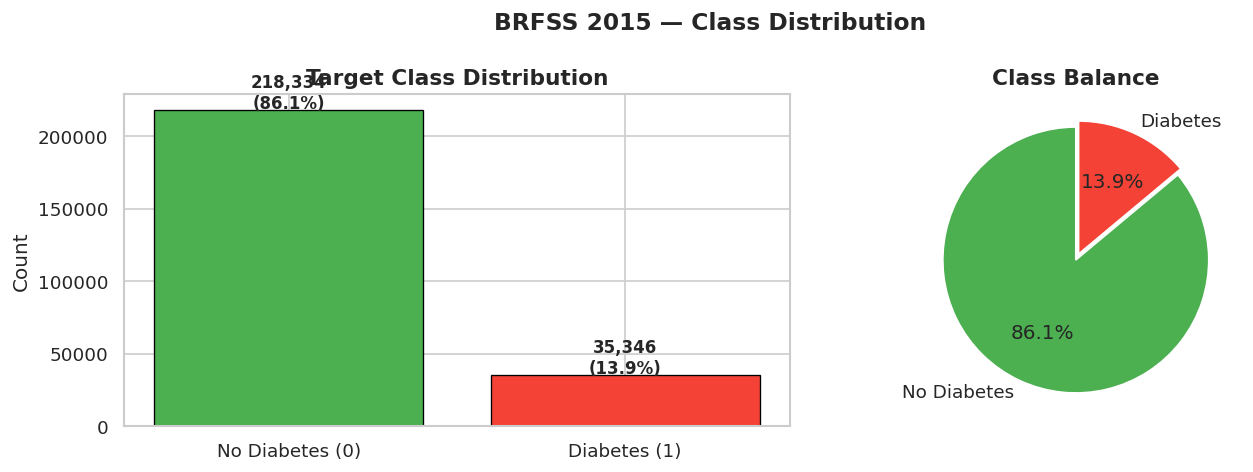

Class ratio: 6.18:1  (imbalanced — SMOTE will be applied)


In [ ]:
counts = df['Diabetes_binary'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'], counts.values,
            color=['#4CAF50', '#F44336'], edgecolor='black', linewidth=0.8)
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

axes[1].pie(counts.values, labels=['No Diabetes', 'Diabetes'],
            colors=['#4CAF50', '#F44336'], autopct='%1.1f%%',
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Class Balance', fontsize=13, fontweight='bold')

plt.suptitle('BRFSS 2015 — Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('01_class_distribution.png', bbox_inches='tight')
plt.show()
print(f"Class ratio: {counts[0]/counts[1]:.2f}:1  (imbalanced — SMOTE will be applied)")

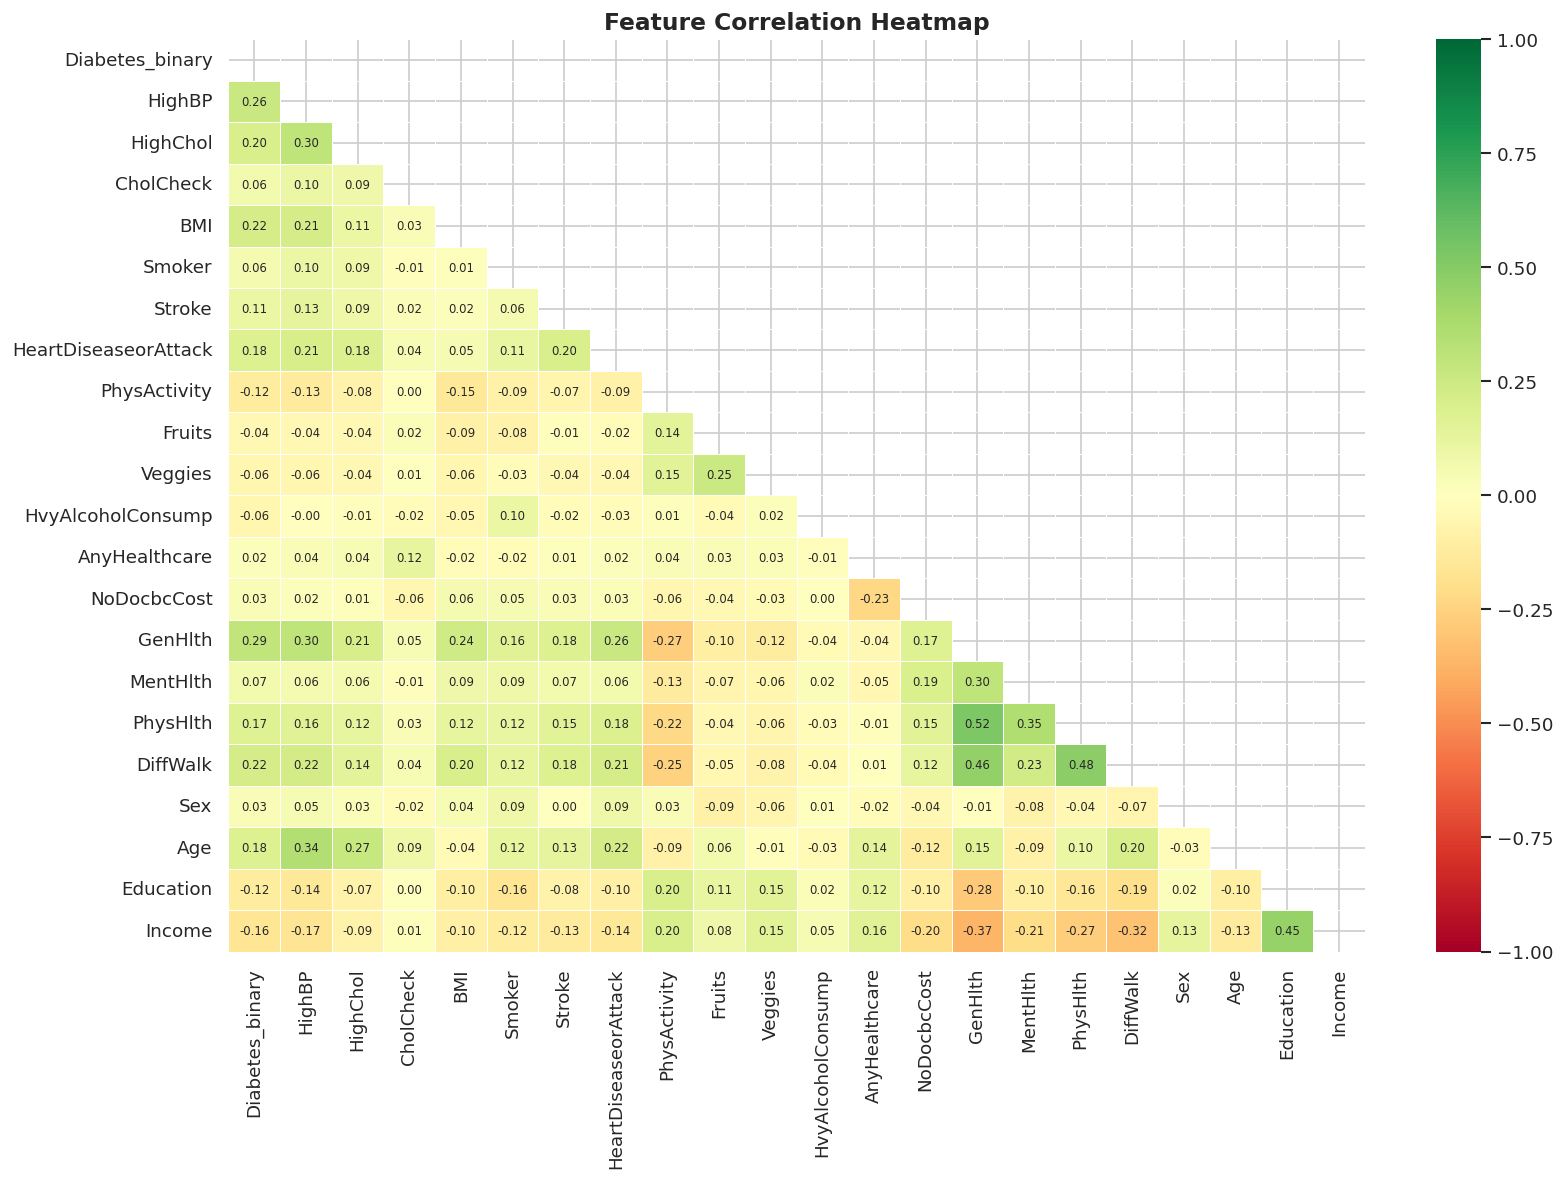

In [ ]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.4, annot_kws={'size': 7}, center=0,
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_correlation_heatmap.png', bbox_inches='tight')
plt.show()

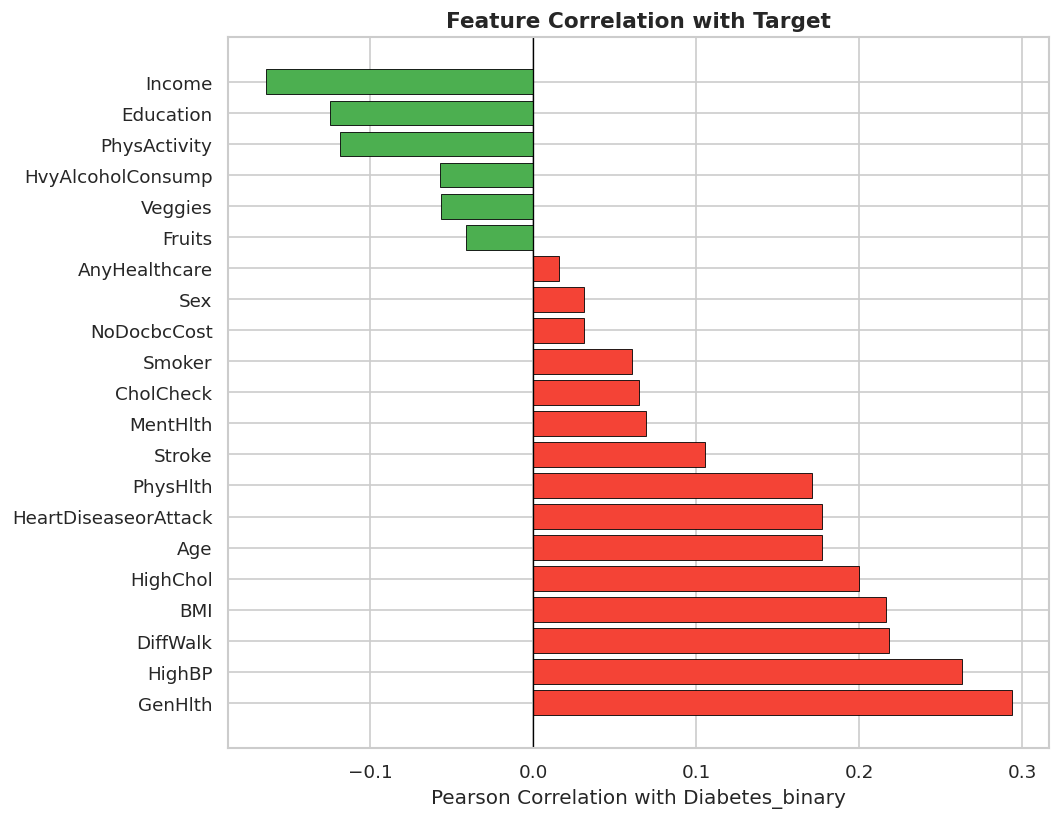

In [ ]:
target_corr = df.corr()['Diabetes_binary'].drop('Diabetes_binary').sort_values(ascending=False)
colors = ['#F44336' if v > 0 else '#4CAF50' for v in target_corr.values]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Diabetes_binary', fontsize=12)
ax.set_title('Feature Correlation with Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03_target_correlation.png', bbox_inches='tight')
plt.show()

## 4. Preprocessing

Pipeline: remove duplicates → median imputation → 80/20 stratified split → StandardScaler (train-fit only) → SMOTE on training set only.

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

TARGET = 'Diabetes_binary'
FEATURE_NAMES = [c for c in df.columns if c != TARGET]

X = df[FEATURE_NAMES].values
y = df[TARGET].values.astype(int)

imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Train (after SMOTE): {X_train_res.shape}  |  Test: {X_test_scaled.shape}")
print(f"Class 0: {sum(y_train_res==0):,}  |  Class 1: {sum(y_train_res==1):,}")

Train (after SMOTE): (311002, 21)  |  Test: (45895, 21)
Class 0: 155,501  |  Class 1: 155,501


In [ ]:
beta = 1.5  # F-beta parameter (same as LightGBM notebook)

In [ ]:
import numpy as np
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

shap_n = 1000
shap_idx = np.random.choice(len(X_test_scaled), size=shap_n, replace=False)
pos_indices = np.where(y_test == 1)[0][:4]

---
## 5. Gradient Boosting Model

In [ ]:
gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=RANDOM_STATE
)

print("Training Gradient Boosting (approx 2-3 min)...")
gb_model.fit(X_train_res, y_train_res)
print("Gradient Boosting trained.")

Training Gradient Boosting (approx 2-3 min)...
Gradient Boosting trained.


### 5.1 Threshold Tuning (F-beta, beta=1.5)

In [ ]:
gb_prob = gb_model.predict_proba(X_test_scaled)[:, 1]

prec_g, rec_g, thr_g = precision_recall_curve(y_test, gb_prob)
fb_g = (1 + beta**2) * (prec_g * rec_g) / ((beta**2 * prec_g) + rec_g + 1e-9)
best_idx_g = fb_g.argmax()
GB_THRESHOLD = thr_g[best_idx_g]
print(f"Gradient Boosting optimal threshold: {GB_THRESHOLD:.4f}")

Gradient Boosting optimal threshold: 0.2401


### 5.2 Evaluation

In [ ]:
gb_pred = (gb_prob >= GB_THRESHOLD).astype(int)

gb_acc  = accuracy_score(y_test, gb_pred)
gb_prec = precision_score(y_test, gb_pred)
gb_rec  = recall_score(y_test, gb_pred)
gb_f1   = f1_score(y_test, gb_pred)
gb_f2   = fbeta_score(y_test, gb_pred, beta=2)
gb_auc  = roc_auc_score(y_test, gb_prob)
gb_ap   = average_precision_score(y_test, gb_prob)

print("=" * 48)
print("  GRADIENT BOOSTING — EVALUATION RESULTS")
print("=" * 48)
print(f"  Threshold  : {GB_THRESHOLD:.4f}")
print(f"  Accuracy   : {gb_acc:.4f}")
print(f"  Precision  : {gb_prec:.4f}")
print(f"  Recall     : {gb_rec:.4f}")
print(f"  F1         : {gb_f1:.4f}")
print(f"  F2         : {gb_f2:.4f}")
print(f"  AUC-ROC    : {gb_auc:.4f}")
print(f"  Avg Prec   : {gb_ap:.4f}")
print("=" * 48)
print(classification_report(y_test, gb_pred, target_names=['No Diabetes', 'Diabetes']))

  GRADIENT BOOSTING — EVALUATION RESULTS
  Threshold  : 0.2401
  Accuracy   : 0.7036
  Precision  : 0.3141
  Recall     : 0.7923
  F1         : 0.4498
  F2         : 0.6073
  AUC-ROC    : 0.8145
  Avg Prec   : 0.4326
              precision    recall  f1-score   support

 No Diabetes       0.95      0.69      0.80     38876
    Diabetes       0.31      0.79      0.45      7019

    accuracy                           0.70     45895
   macro avg       0.63      0.74      0.62     45895
weighted avg       0.85      0.70      0.74     45895



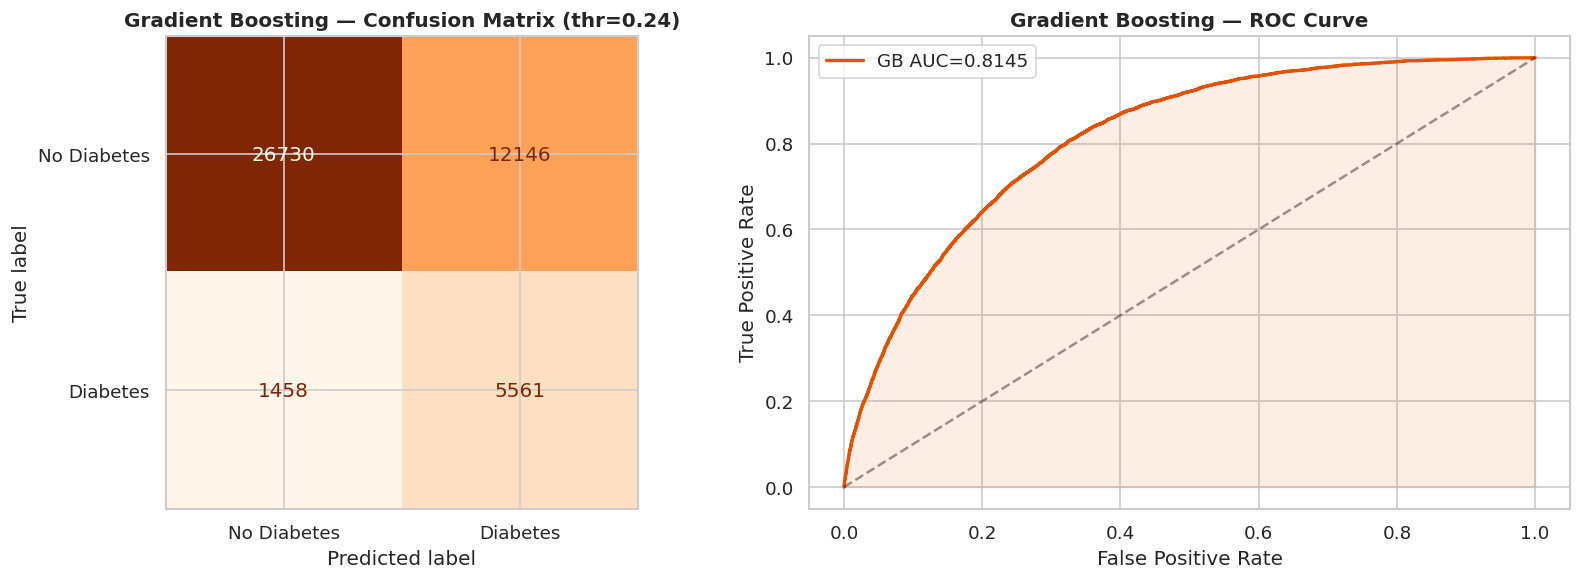

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_g = confusion_matrix(y_test, gb_pred)
ConfusionMatrixDisplay(cm_g, display_labels=['No Diabetes', 'Diabetes']).plot(
    ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title(f'Gradient Boosting — Confusion Matrix (thr={GB_THRESHOLD:.2f})',
                  fontsize=12, fontweight='bold')

fpr_g, tpr_g, _ = roc_curve(y_test, gb_prob)
axes[1].plot(fpr_g, tpr_g, color='#E65100', lw=2, label=f'GB AUC={gb_auc:.4f}')
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].fill_between(fpr_g, tpr_g, alpha=0.1, color='#E65100')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Gradient Boosting — ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig('14_gb_evaluation.png', bbox_inches='tight')
plt.show()

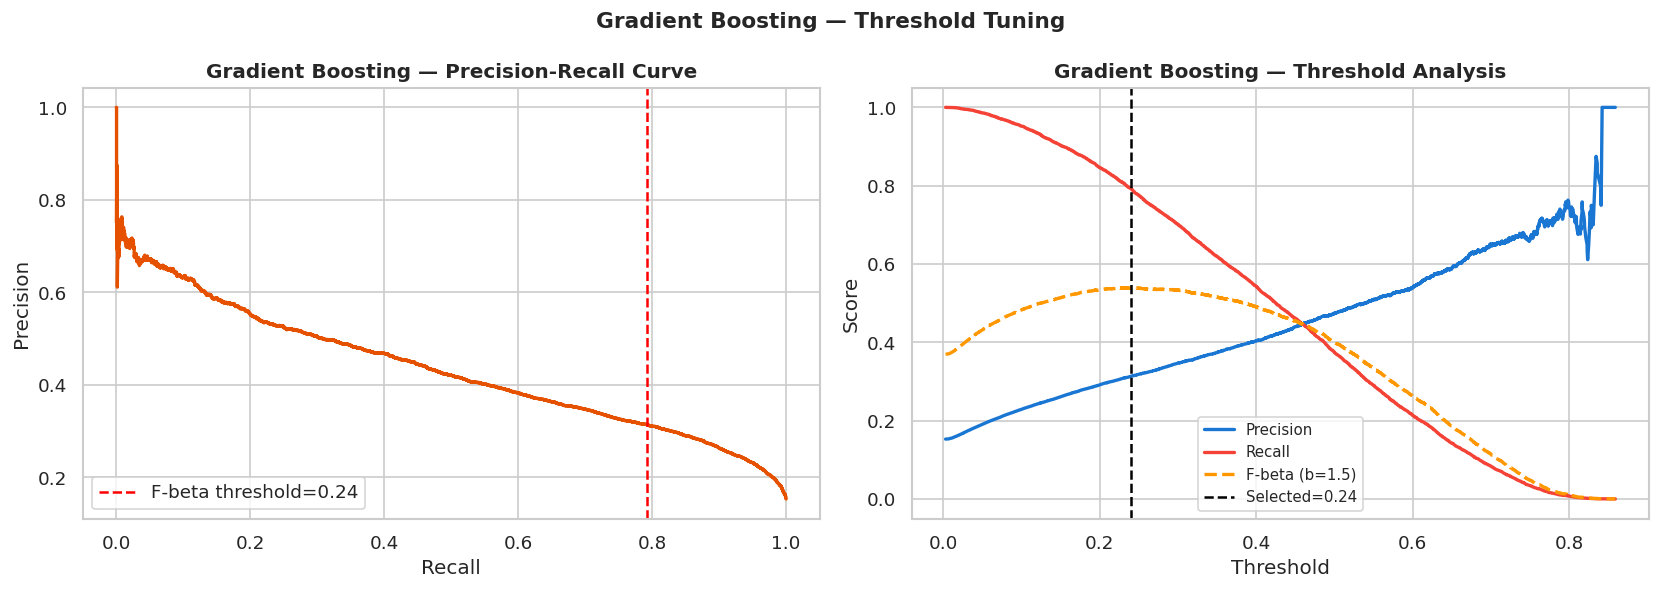

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rec_g[:-1], prec_g[:-1], color='#E65100', lw=2)
axes[0].axvline(rec_g[best_idx_g], color='red', linestyle='--', lw=1.5,
                label=f'F-beta threshold={GB_THRESHOLD:.2f}')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Gradient Boosting — Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[0].legend()

axes[1].plot(thr_g, prec_g[:-1], color='#1976D2', lw=2, label='Precision')
axes[1].plot(thr_g, rec_g[:-1],  color='#F44336', lw=2, label='Recall')
axes[1].plot(thr_g, fb_g[:-1],   color='#FF9800', lw=2, linestyle='--',
             label=f'F-beta (b={beta})')
axes[1].axvline(GB_THRESHOLD, color='black', linestyle='--', lw=1.5,
                label=f'Selected={GB_THRESHOLD:.2f}')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Score')
axes[1].set_title('Gradient Boosting — Threshold Analysis', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
plt.suptitle('Gradient Boosting — Threshold Tuning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('15_gb_threshold.png', bbox_inches='tight')
plt.show()

In [ ]:
cv_gb = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.05, max_depth=5,
    random_state=RANDOM_STATE
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc_g = cross_val_score(cv_gb, X_train_scaled, y_train,
                           cv=skf, scoring='roc_auc', n_jobs=-1)
cv_f1_g  = cross_val_score(cv_gb, X_train_scaled, y_train,
                           cv=skf, scoring='f1', n_jobs=-1)
print(f"Gradient Boosting 5-Fold CV  AUC: {cv_auc_g.mean():.4f} +/- {cv_auc_g.std():.4f}")
print(f"Gradient Boosting 5-Fold CV  F1 : {cv_f1_g.mean():.4f} +/- {cv_f1_g.std():.4f}")

Gradient Boosting 5-Fold CV  AUC: 0.8148 +/- 0.0010
Gradient Boosting 5-Fold CV  F1 : 0.2283 +/- 0.0062


### 5.3 XAI — Gradient Boosting

#### SHAP

In [ ]:
print("Computing SHAP values for Gradient Boosting...")
gb_explainer = shap.TreeExplainer(gb_model)
X_shap_gb = pd.DataFrame(X_test_scaled[shap_idx], columns=FEATURE_NAMES)

gb_shap_vals = gb_explainer.shap_values(X_shap_gb)
print(f"SHAP computed. Shape: {gb_shap_vals.shape}")

Computing SHAP values for Gradient Boosting...
SHAP computed. Shape: (1000, 21)


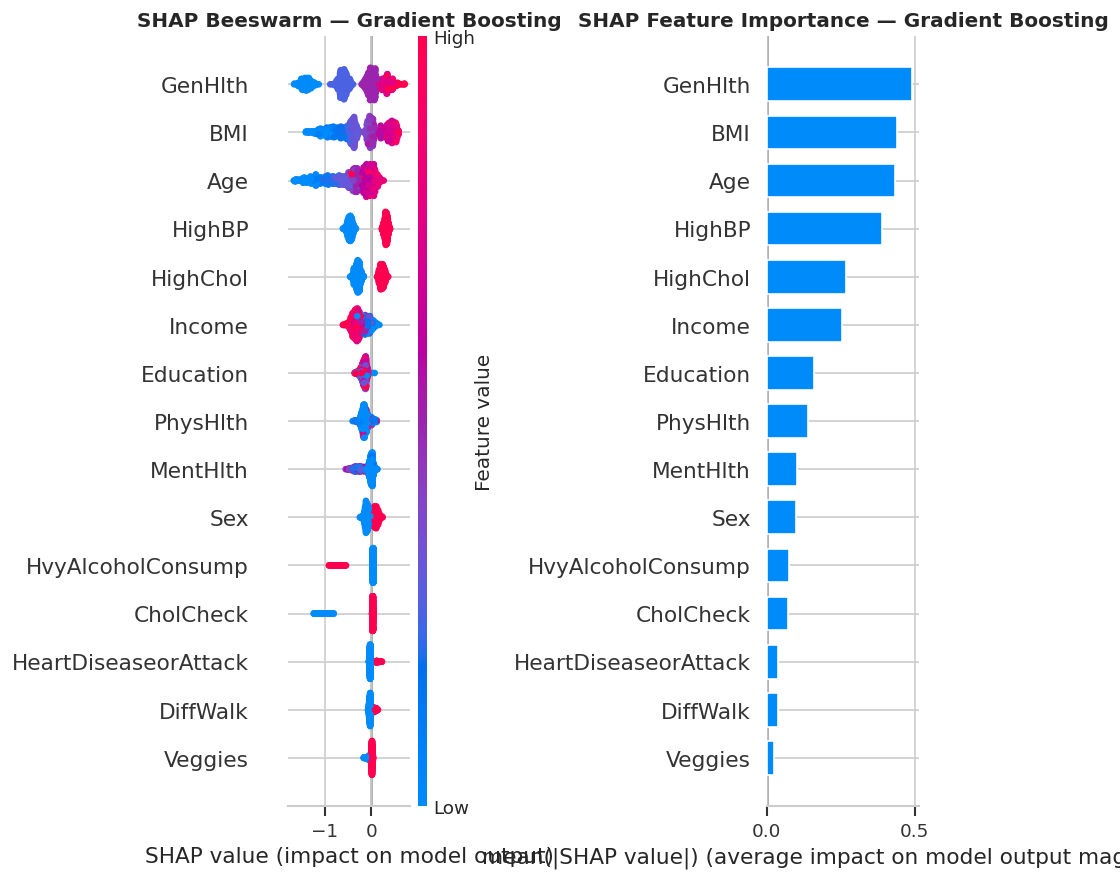

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.summary_plot(gb_shap_vals, X_shap_gb, feature_names=FEATURE_NAMES,
                  plot_type='dot', show=False, max_display=15)
axes[0].set_title('SHAP Beeswarm — Gradient Boosting', fontsize=12, fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(gb_shap_vals, X_shap_gb, feature_names=FEATURE_NAMES,
                  plot_type='bar', show=False, max_display=15)
axes[1].set_title('SHAP Feature Importance — Gradient Boosting', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('16_gb_shap_global.png', bbox_inches='tight')
plt.show()

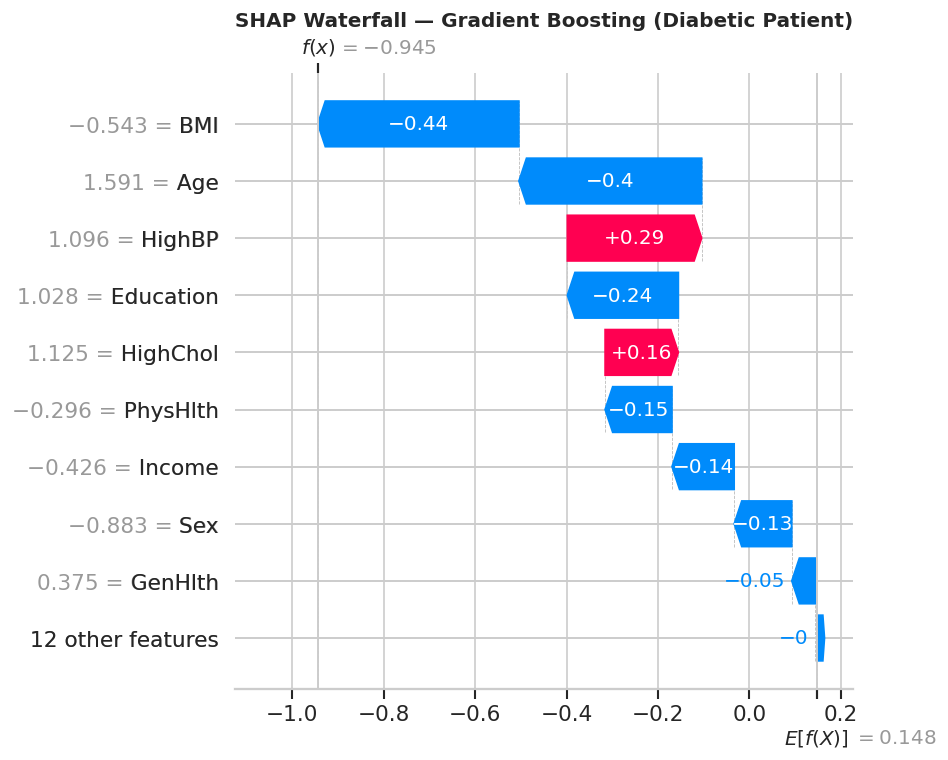

In [ ]:
exp_val_g = gb_explainer.expected_value
if isinstance(exp_val_g, list):
    exp_val_g = exp_val_g[1]

pos_in_shap_g = np.where(y_test[shap_idx] == 1)[0][0]
shap.waterfall_plot(shap.Explanation(
    values=gb_shap_vals[pos_in_shap_g],
    base_values=exp_val_g,
    data=X_shap_gb.iloc[pos_in_shap_g].values,
    feature_names=FEATURE_NAMES
), show=False)
plt.title('SHAP Waterfall — Gradient Boosting (Diabetic Patient)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('17_gb_shap_waterfall.png', bbox_inches='tight')
plt.show()

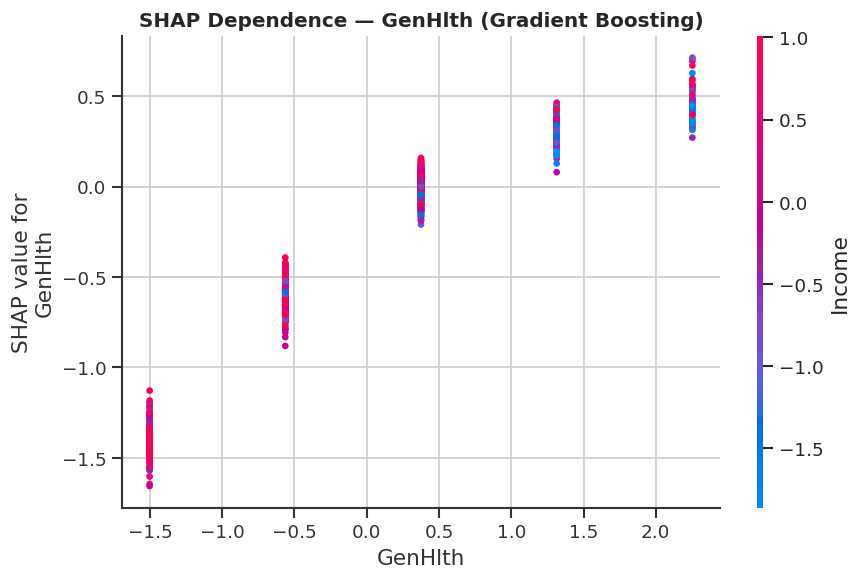

In [ ]:
top_feat_gb = pd.Series(np.abs(gb_shap_vals).mean(axis=0), index=FEATURE_NAMES).idxmax()
shap.dependence_plot(top_feat_gb, gb_shap_vals, X_shap_gb,
                     feature_names=FEATURE_NAMES, show=False)
plt.title(f'SHAP Dependence — {top_feat_gb} (Gradient Boosting)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('18_gb_shap_dependence.png', bbox_inches='tight')
plt.show()

#### LIME — Gradient Boosting

LIME GB  P(No Diabetes)=0.361  P(Diabetes)=0.639


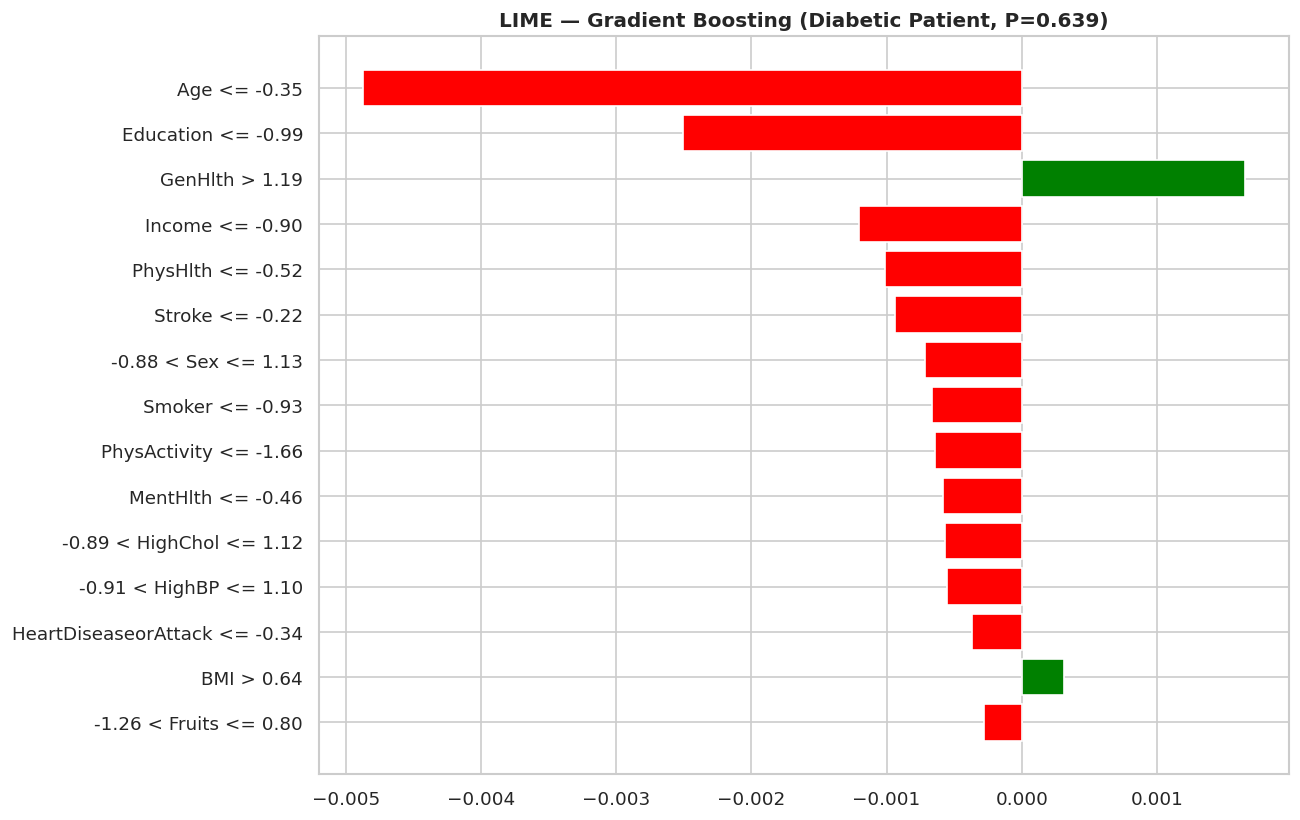

In [ ]:
lime_explainer_gb = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_res,
    feature_names=FEATURE_NAMES,
    class_names=['No Diabetes', 'Diabetes'],
    mode='classification',
    random_state=RANDOM_STATE
)

pos_idx_g = np.where(y_test == 1)[0][0]
lime_exp_g = lime_explainer_gb.explain_instance(
    data_row=X_test_scaled[pos_idx_g],
    predict_fn=gb_model.predict_proba,
    num_features=15,
    num_samples=2000
)
prob_g = gb_model.predict_proba([X_test_scaled[pos_idx_g]])[0]
print(f"LIME GB  P(No Diabetes)={prob_g[0]:.3f}  P(Diabetes)={prob_g[1]:.3f}")

fig = lime_exp_g.as_pyplot_figure(label=1)
fig.set_size_inches(11, 7)
plt.title(f'LIME — Gradient Boosting (Diabetic Patient, P={prob_g[1]:.3f})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('19_gb_lime_single.png', bbox_inches='tight')
plt.show()

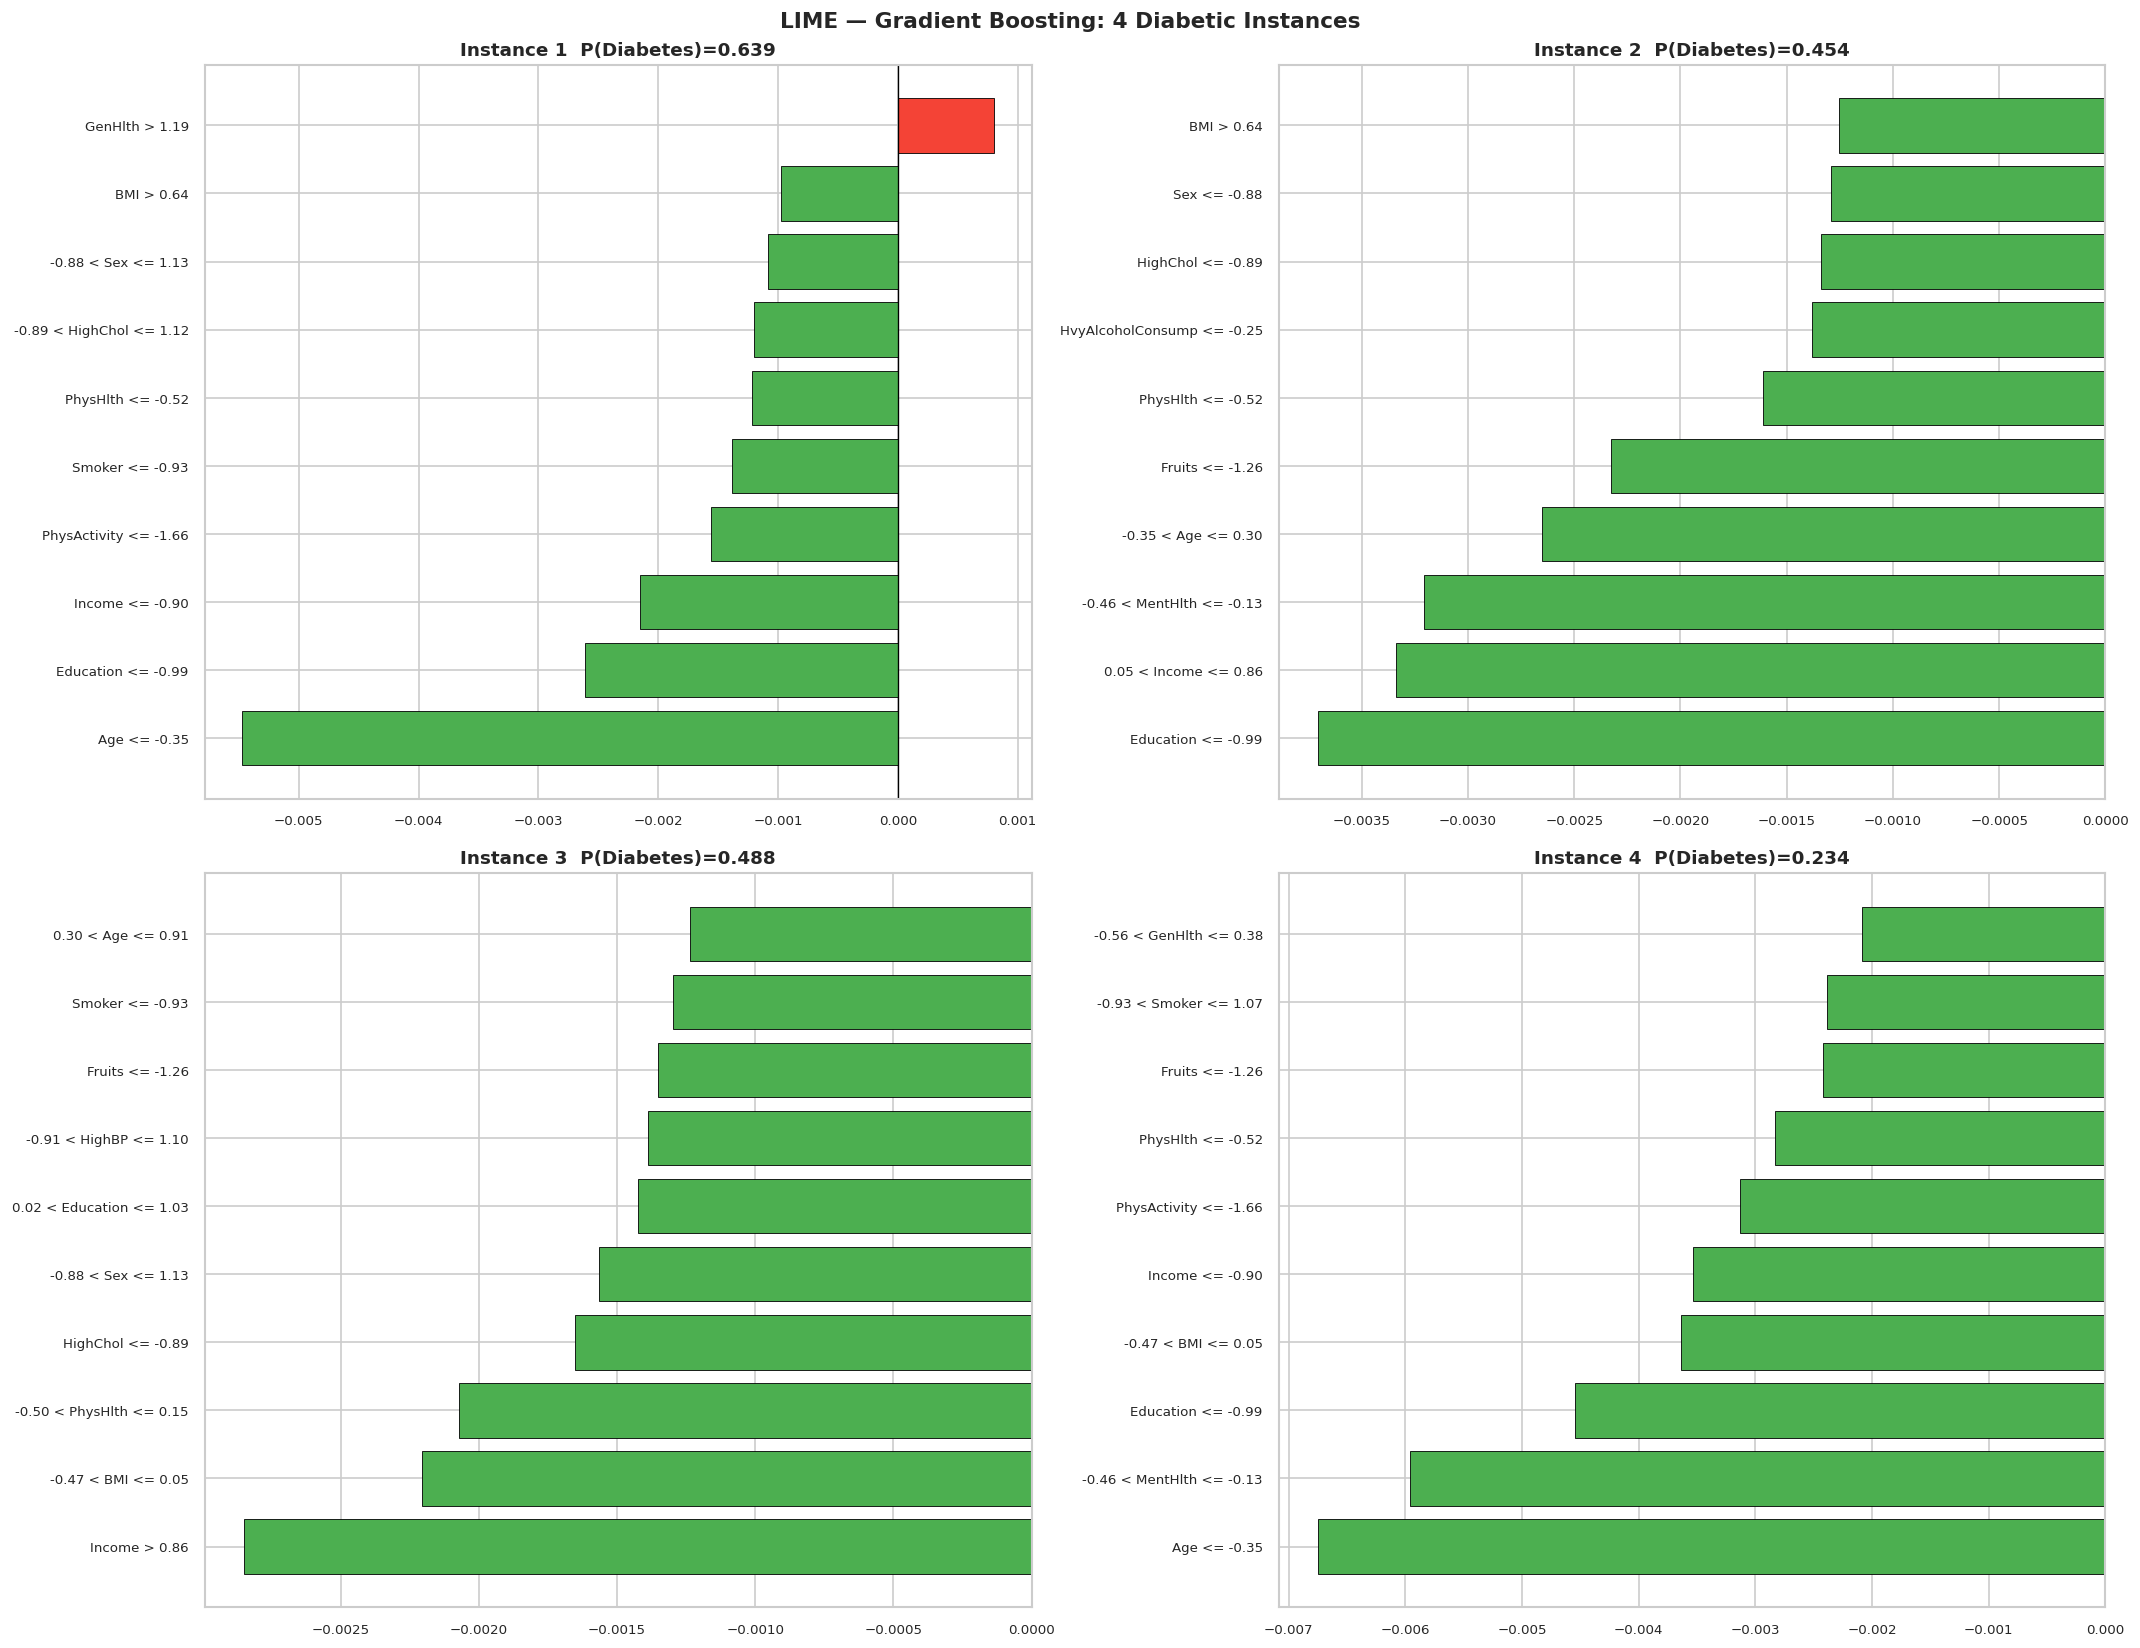

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()
for i, idx in enumerate(pos_indices):
    inst = X_test_scaled[idx]
    exp = lime_explainer_gb.explain_instance(
        data_row=inst, predict_fn=gb_model.predict_proba,
        num_features=10, num_samples=1000
    )
    vals = exp.as_list(label=1)
    feats = [v[0] for v in vals]; weights = [v[1] for v in vals]
    colors = ['#F44336' if w > 0 else '#4CAF50' for w in weights]
    axes[i].barh(feats, weights, color=colors, edgecolor='black', linewidth=0.5)
    axes[i].axvline(0, color='black', linewidth=0.8)
    prob = gb_model.predict_proba([inst])[0][1]
    axes[i].set_title(f'Instance {i+1}  P(Diabetes)={prob:.3f}', fontsize=11, fontweight='bold')
    axes[i].tick_params(labelsize=8)
plt.suptitle('LIME — Gradient Boosting: 4 Diabetic Instances', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('20_gb_lime_multi.png', bbox_inches='tight')
plt.show()

#### Permutation Importance — Gradient Boosting

Computing permutation importance for Gradient Boosting (10 repeats)...


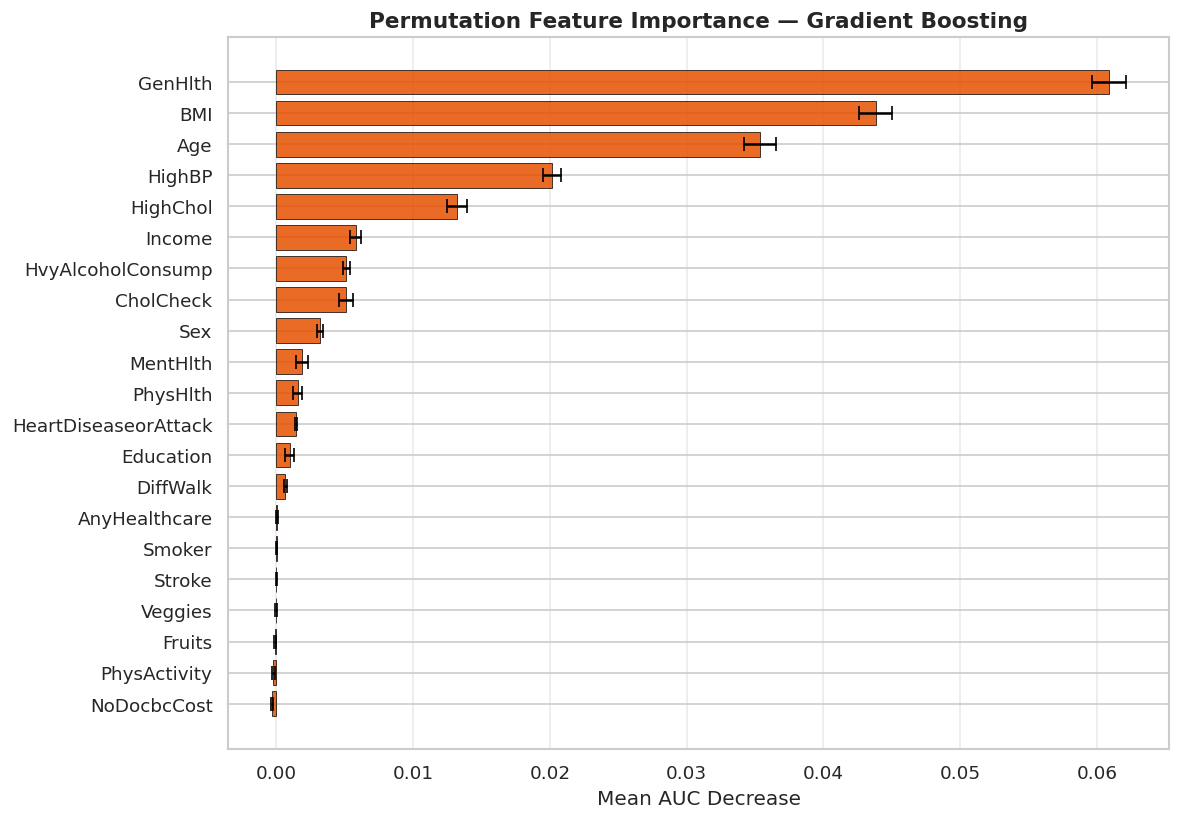

In [ ]:
print("Computing permutation importance for Gradient Boosting (10 repeats)...")
perm_gb = permutation_importance(
    gb_model, X_test_scaled, y_test,
    n_repeats=10, random_state=RANDOM_STATE, scoring='roc_auc', n_jobs=-1
)
pfi_gb = pd.DataFrame({
    'Feature'   : FEATURE_NAMES,
    'Importance': perm_gb.importances_mean,
    'Std'       : perm_gb.importances_std
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(pfi_gb['Feature'], pfi_gb['Importance'],
         xerr=pfi_gb['Std'], color='#E65100', alpha=0.85,
         edgecolor='black', linewidth=0.5,
         error_kw={'elinewidth': 1.5, 'capsize': 4})
plt.xlabel('Mean AUC Decrease', fontsize=12)
plt.title('Permutation Feature Importance — Gradient Boosting', fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('21_gb_permutation.png', bbox_inches='tight')
plt.show()

#### Partial Dependence Plots — Gradient Boosting

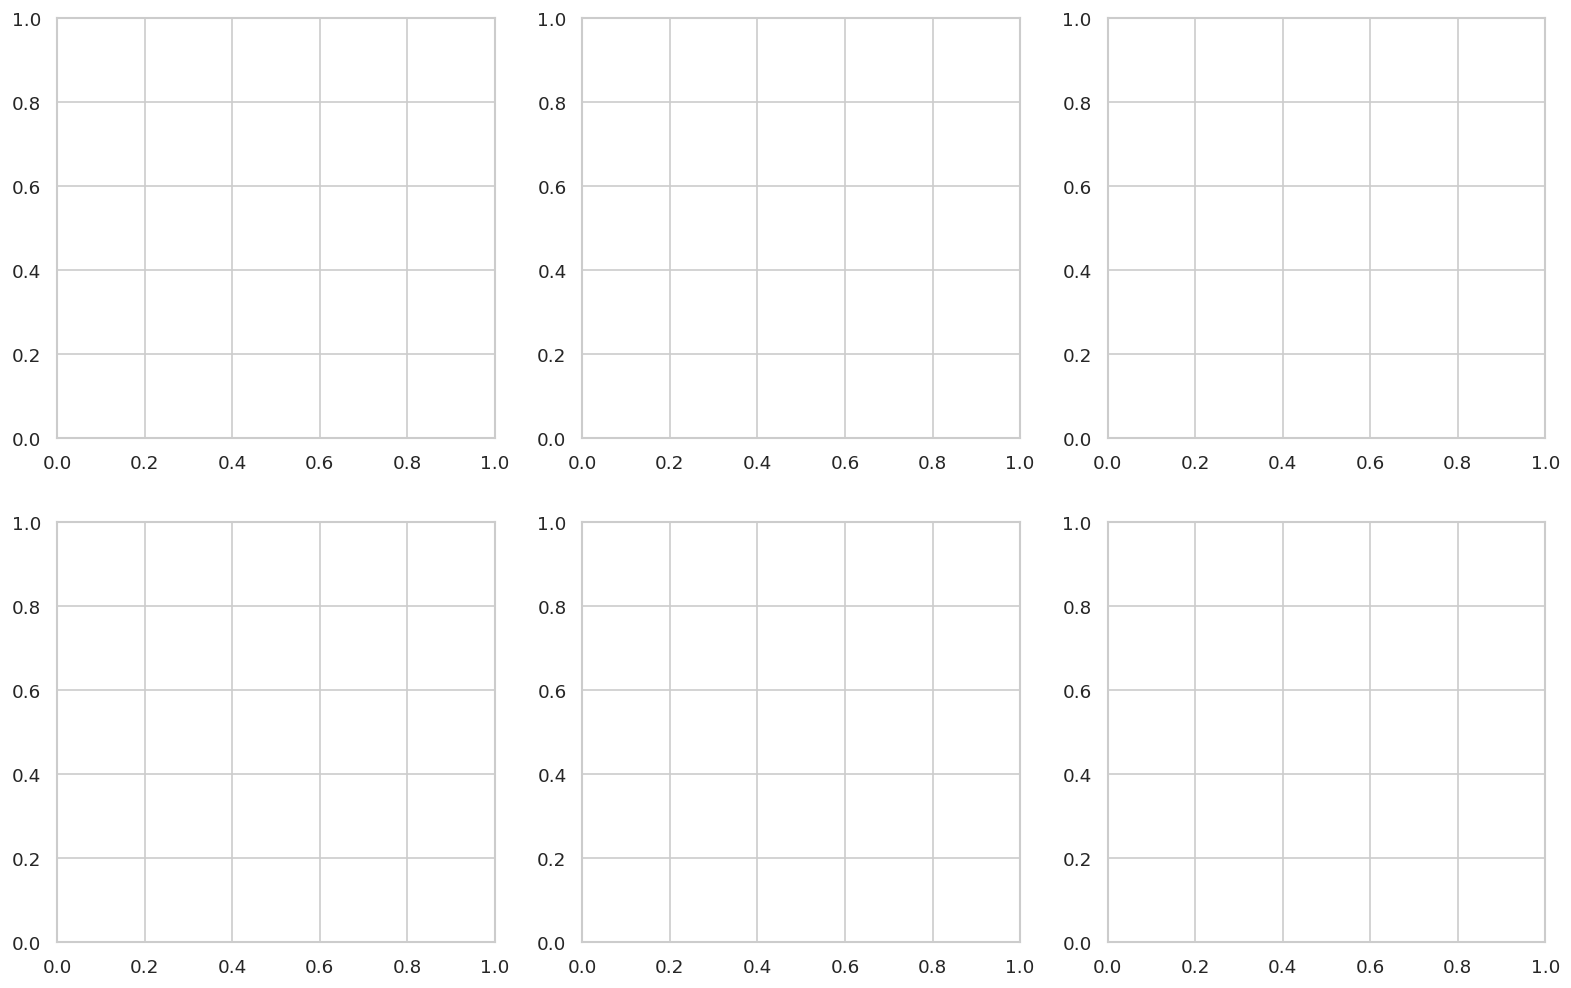

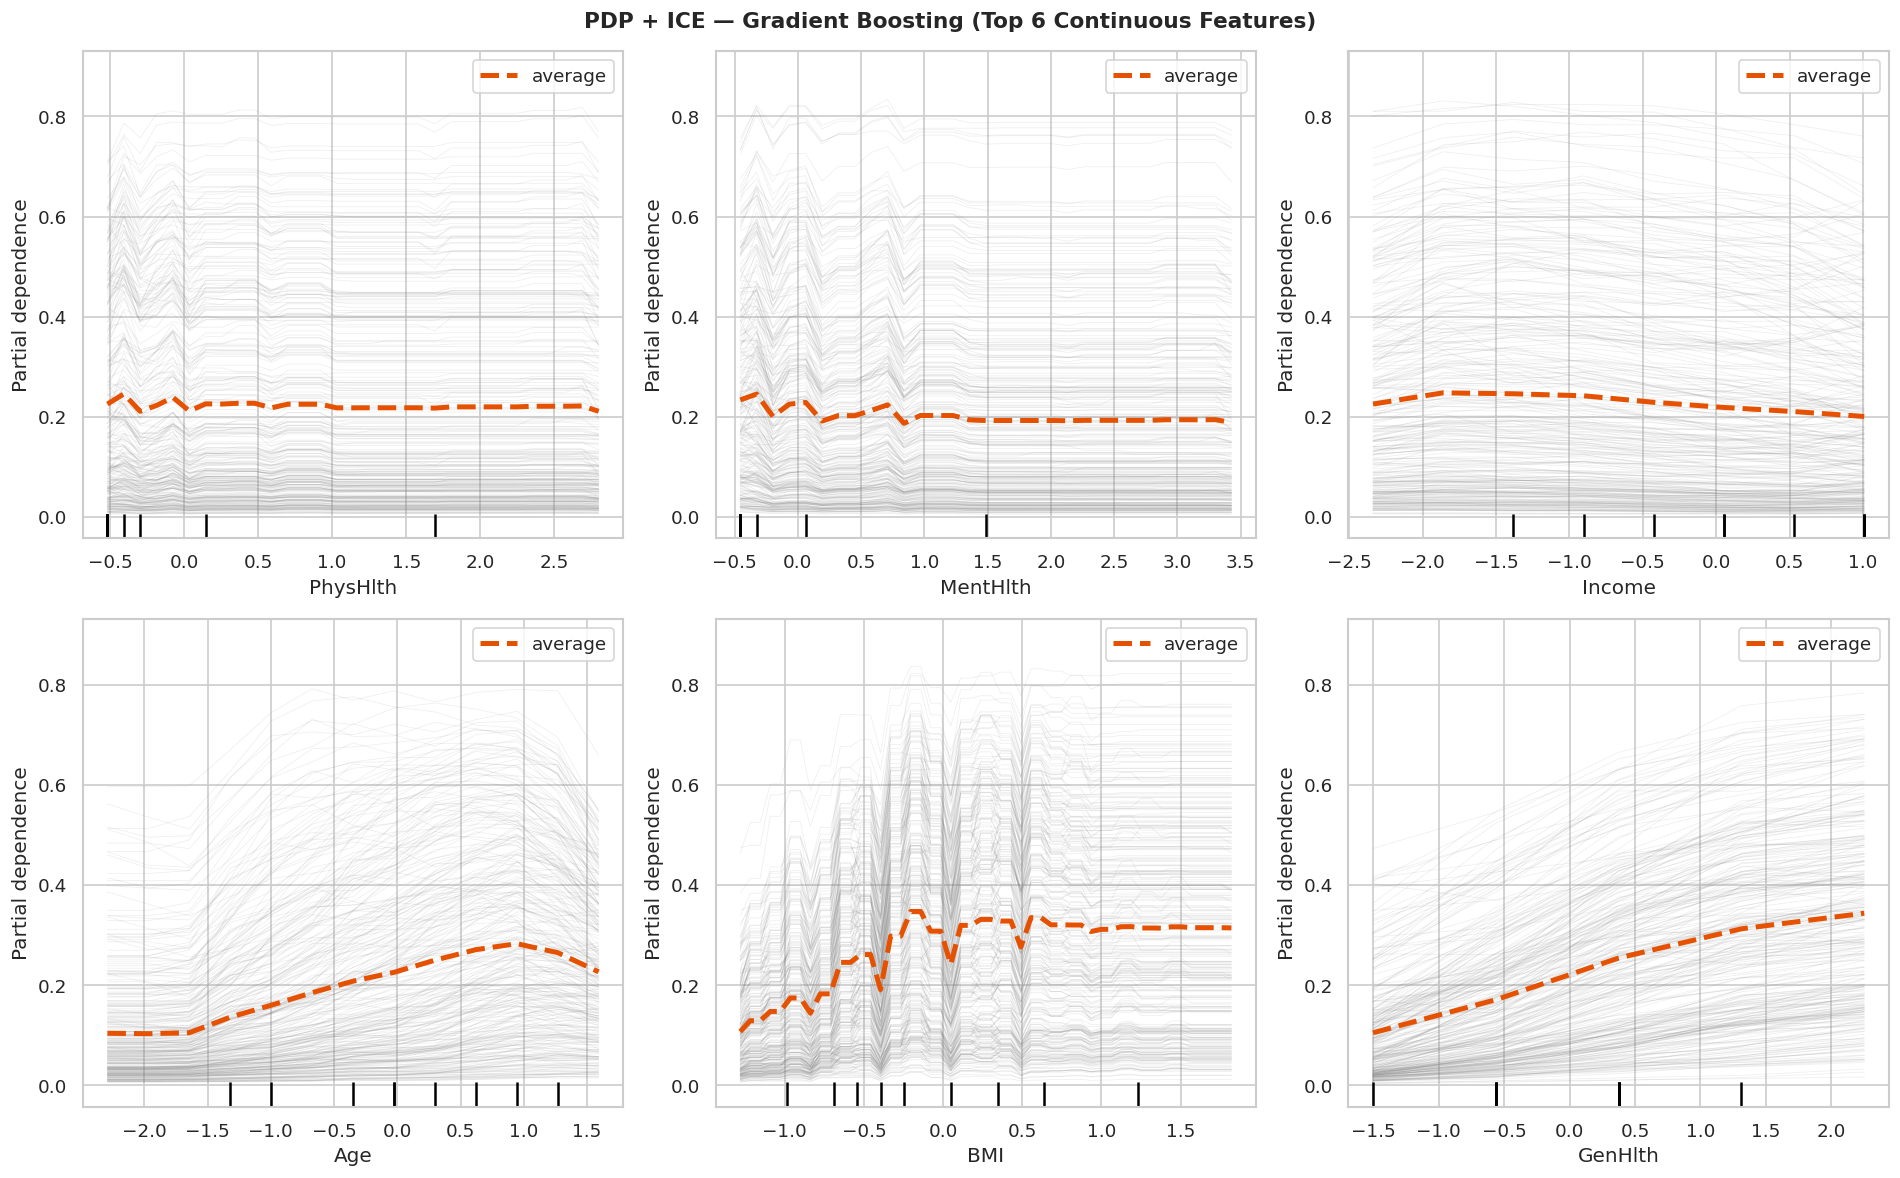

In [ ]:
X_test_df = pd.DataFrame(X_test_scaled, columns=FEATURE_NAMES)

# Get indices of top 6 continuous features for PDP + ICE plots
# Selecting based on importance from pfi_gb and being continuous-like features
continuous_features = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
ranked_continuous_features = pfi_gb[pfi_gb['Feature'].isin(continuous_features)].tail(6)['Feature'].tolist()
top_feat_idx = [FEATURE_NAMES.index(feat) for feat in ranked_continuous_features]

# Get indices for BMI and GenHlth for the 2D PDP
bmi_idx = FEATURE_NAMES.index('BMI')
genhlth_idx = FEATURE_NAMES.index('GenHlth')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
PartialDependenceDisplay.from_estimator(
    gb_model, X_test_df, # Use X_test_df here
    features=top_feat_idx, feature_names=FEATURE_NAMES,
    kind='both', subsample=300, percentiles=(0.05, 0.95),
    grid_resolution=50, ax=axes.flatten(),
    ice_lines_kw={'color': 'grey', 'alpha': 0.12, 'linewidth': 0.5},
    pd_line_kw={'color': '#E65100', 'linewidth': 3}
)
plt.suptitle('PDP + ICE — Gradient Boosting (Top 6 Continuous Features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('22_gb_pdp.png', bbox_inches='tight')
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
PartialDependenceDisplay.from_estimator(
    gb_model, X_test_df.values,
    features=[(bmi_idx, genhlth_idx)], feature_names=FEATURE_NAMES,
    kind='average', ax=ax
)
ax.set_title('2D PDP — BMI x GenHlth (Gradient Boosting)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('23_gb_pdp_2d.png', bbox_inches='tight')
plt.show()